## Step 1: Import Libraries

In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Step 2: Load All EEG Data

Load CSV files from your folder structure organized by words and participants.

In [40]:
# IMPORTANT: Update this path to your data location
BASE_FOLDER = r"C:\AgorAI Hackathon\كلمات"

# Dictionary to store all DataFrames with metadata
dfs_parts = {}

print("Loading EEG data from folders...\n")

# Collect only folders (each folder = word)
word_directories = [
    word
    for word in sorted(os.listdir(BASE_FOLDER))
    if os.path.isdir(os.path.join(BASE_FOLDER, word))
]

for word_index, word in enumerate(word_directories, start=1):
    word_path = os.path.join(BASE_FOLDER, word)
    print(f"Word {word_index}: {word}")

    # Collect only CSV recordings inside this word folder
    csv_files = [
        file
        for file in sorted(os.listdir(word_path))
        if file.lower().endswith(".csv")
    ]

    if not csv_files:
        print("  ⚠ No CSV files found in this folder")
        continue

    for part_index, file in enumerate(csv_files, start=1):
        # Skip files where participant number is 23
        if file.startswith("par.23") or file.startswith("par. 23"):
            print(f"  ⊘ Skipping participant 23: {file}")
            continue

        # Skip duplicate/retake recordings (files with "2_" pattern after participant number)
        if " 2_" in file or "2_EPOCX" in file:
            print(f"  ⊘ Skipping duplicate recording: {file}")
            continue

        var_name = f"df{word_index}_part{part_index}"
        file_path = os.path.join(word_path, file)

        try:
            df = pd.read_csv(file_path, skiprows=1)

            dfs_parts[var_name] = {
                'data': df,
                'word': word,
                'word_index': word_index,
                'participant': part_index,
                'file_path': file_path,
                'filename': file
            }

            globals()[var_name] = df
            print(f"  ✓ {var_name}: {len(df)} samples")

        except Exception as e:
            print(f"  ✗ {var_name}: Error loading - {e}")

print(f"\n{'='*60}")
print("LOADING SUMMARY:")
print(f"  Total recordings: {len(dfs_parts)}")
print(f"  Total words: {len({v['word'] for v in dfs_parts.values()})}")
print(f"  Total samples: {sum(len(v['data']) for v in dfs_parts.values()):,}")
print(f"  Expected: 16 words × 22 participants = 352 recordings")
print(f"{'='*60}")

Loading EEG data from folders...

Word 1: اختر
  ✓ df1_part1: 1480 samples
  ✓ df1_part2: 1382 samples
  ✓ df1_part3: 1369 samples
  ✓ df1_part4: 1389 samples
  ✓ df1_part5: 1376 samples
  ✓ df1_part6: 1384 samples
  ✓ df1_part7: 1381 samples
  ✓ df1_part8: 1405 samples
  ⊘ Skipping duplicate recording: par.17 2_EPOCX_206412_2023.12.24T13.26.55+03.00.md.csv
  ✓ df1_part10: 1388 samples
  ✓ df1_part11: 1380 samples
  ✓ df1_part12: 1386 samples
  ✓ df1_part13: 1380 samples
  ✓ df1_part14: 1413 samples
  ✓ df1_part15: 1381 samples
  ✓ df1_part16: 1379 samples
  ✓ df1_part17: 1386 samples
  ✓ df1_part18: 1384 samples
  ✓ df1_part19: 1384 samples
  ✓ df1_part20: 1394 samples
  ✓ df1_part21: 1390 samples
  ✓ df1_part22: 1376 samples
  ✓ df1_part23: 1379 samples
Word 2: اسفل
  ✓ df2_part1: 1851 samples
  ✓ df2_part2: 1382 samples
  ✓ df2_part3: 1377 samples
  ✓ df2_part4: 1384 samples
  ✓ df2_part5: 1386 samples
  ✓ df2_part6: 1407 samples
  ✓ df2_part7: 1401 samples
  ✓ df2_part8: 1386 sampl

## Step 3: Inspect Data Structure

Check what columns are available in the data.

In [41]:
# Get a sample DataFrame to inspect
if dfs_parts:
    sample_key = list(dfs_parts.keys())[0]
    sample_df = dfs_parts[sample_key]['data']

    print(f"Sample DataFrame: {sample_key}")
    print(f"Shape: {sample_df.shape}")
    print(f"\nAll columns ({len(sample_df.columns)}):")
    for i, col in enumerate(sample_df.columns, 1):
        print(f"{i:3}. {col}")

    # Check first few rows
    print(f"\nFirst 3 rows:")
    display(sample_df.head(3))

Sample DataFrame: df1_part1
Shape: (1480, 68)

All columns (68):
  1. Timestamp
  2. OriginalTimestamp
  3. EEG.Counter
  4. EEG.Interpolated
  5. EEG.AF3
  6. EEG.F7
  7. EEG.F3
  8. EEG.FC5
  9. EEG.T7
 10. EEG.P7
 11. EEG.O1
 12. EEG.O2
 13. EEG.P8
 14. EEG.T8
 15. EEG.FC6
 16. EEG.F4
 17. EEG.F8
 18. EEG.AF4
 19. EEG.RawCq
 20. EEG.Battery
 21. EEG.BatteryPercent
 22. MarkerIndex
 23. MarkerType
 24. MarkerValueInt
 25. EEG.MarkerHardware
 26. CQ.AF3
 27. CQ.F7
 28. CQ.F3
 29. CQ.FC5
 30. CQ.T7
 31. CQ.P7
 32. CQ.O1
 33. CQ.O2
 34. CQ.P8
 35. CQ.T8
 36. CQ.FC6
 37. CQ.F4
 38. CQ.F8
 39. CQ.AF4
 40. CQ.Overall
 41. EQ.SampleRateQuality
 42. EQ.OVERALL
 43. EQ.AF3
 44. EQ.F7
 45. EQ.F3
 46. EQ.FC5
 47. EQ.T7
 48. EQ.P7
 49. EQ.O1
 50. EQ.O2
 51. EQ.P8
 52. EQ.T8
 53. EQ.FC6
 54. EQ.F4
 55. EQ.F8
 56. EQ.AF4
 57. MOT.CounterMems
 58. MOT.InterpolatedMems
 59. MOT.Q0
 60. MOT.Q1
 61. MOT.Q2
 62. MOT.Q3
 63. MOT.AccX
 64. MOT.AccY
 65. MOT.AccZ
 66. MOT.MagX
 67. MOT.MagY
 68. MOT.MagZ


,Timestamp,OriginalTimestamp,EEG.Counter,EEG.Interpolated,EEG.AF3,EEG.F7,EEG.F3,EEG.FC5,EEG.T7,EEG.P7,...,MOT.Q0,MOT.Q1,MOT.Q2,MOT.Q3,MOT.AccX,MOT.AccY,MOT.AccZ,MOT.MagX,MOT.MagY,MOT.MagZ
0,1.702803e+09,1.702803e+09,113.0,0.0,4263.846191,4198.333496,4347.563965,4271.153809,4153.717773,4105.256348,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.702803e+09,1.702803e+09,114.0,0.0,4240.897461,4183.974121,4315.128418,4247.051270,4145.897461,4113.846191,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.702803e+09,1.702803e+09,115.0,0.0,4230.128418,4169.230957,4297.307617,4230.256348,4141.538574,4131.025879,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df1_part10.columns

Index(['Timestamp', 'OriginalTimestamp', 'EEG.Counter', 'EEG.Interpolated',
       'EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 'EEG.P7', 'EEG.O1',
       'EEG.O2', 'EEG.P8', 'EEG.T8', 'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4',
       'EEG.RawCq', 'EEG.Battery', 'EEG.BatteryPercent', 'MarkerIndex',
       'MarkerType', 'MarkerValueInt', 'EEG.MarkerHardware', 'CQ.AF3', 'CQ.F7',
       'CQ.F3', 'CQ.FC5', 'CQ.T7', 'CQ.P7', 'CQ.O1', 'CQ.O2', 'CQ.P8', 'CQ.T8',
       'CQ.FC6', 'CQ.F4', 'CQ.F8', 'CQ.AF4', 'CQ.Overall',
       'EQ.SampleRateQuality', 'EQ.OVERALL', 'EQ.AF3', 'EQ.F7', 'EQ.F3',
       'EQ.FC5', 'EQ.T7', 'EQ.P7', 'EQ.O1', 'EQ.O2', 'EQ.P8', 'EQ.T8',
       'EQ.FC6', 'EQ.F4', 'EQ.F8', 'EQ.AF4', 'MOT.CounterMems',
       'MOT.InterpolatedMems', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3',
       'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],
      dtype='object')

## Step 4: Data Cleaning

Remove poor quality samples based on:
- EQ values
- Interpolated samples
- Missing data

In [43]:
def clean_eeg_dataframe(df, eq_threshold=2, remove_columns=True):
    """
    Clean a single EEG DataFrame.

    Parameters:
    -----------
    df : pandas.DataFrame
        Raw EEG data
    eq_threshold : int
        Minimum EQ.Overall value. Default is 2
        EQ.Overall 0 or 1 → will be removed
    remove_columns : bool
        Whether to drop unnecessary columns

    Returns:
    --------
    cleaned_df : pandas.DataFrame
    stats : dict
    """
    original_length = len(df)
    cleaned_df = df.copy()

    # Remove interpolated samples
    if 'EEG.Interpolated' in cleaned_df.columns:
        interpolated_count = (cleaned_df['EEG.Interpolated'] != 0).sum()
        cleaned_df = cleaned_df[cleaned_df['EEG.Interpolated'] == 0]
    else:
        interpolated_count = 0

    # Remove rows where EQ.Overall is 0 or 1
    if 'EQ.Overall' in cleaned_df.columns:
        poor_quality_mask = cleaned_df['EQ.Overall'] < eq_threshold
        poor_quality_count = poor_quality_mask.sum()
        cleaned_df = cleaned_df[~poor_quality_mask]
    elif 'EQ.OVERALL' in cleaned_df.columns:
        poor_quality_mask = cleaned_df['EQ.OVERALL'] < eq_threshold
        poor_quality_count = poor_quality_mask.sum()
        cleaned_df = cleaned_df[~poor_quality_mask]
    else:
        poor_quality_count = 0

    # Remove rows with missing EEG values
    eeg_columns = [col for col in cleaned_df.columns if col.startswith('EEG.') and
                   col not in ['EEG.Counter', 'EEG.Interpolated', 'EEG.RawCq',
                               'EEG.Battery', 'EEG.BatteryPercent', 'EEG.MarkerHardware']]

    if eeg_columns:
        missing_eeg_count = cleaned_df[eeg_columns].isna().any(axis=1).sum()
        cleaned_df = cleaned_df.dropna(subset=eeg_columns)
    else:
        missing_eeg_count = 0

    # Drop unnecessary columns
    if remove_columns:
        columns_to_drop = ['Timestamp', 'OriginalTimestamp', 'EEG.Counter', 'EEG.Interpolated',
                           'EEG.RawCq', 'EEG.Battery', 'EEG.BatteryPercent', 'EEG.MarkerHardware',
                           'MarkerIndex', 'MarkerType', 'MarkerValueInt']
        # Also drop CQ, EQ and MOT columns as they're not needed for EEG analysis
        columns_to_drop += [
            col for col in cleaned_df.columns if col.startswith(('CQ.', 'EQ.', 'MOT.'))]

        columns_to_drop = [
            col for col in columns_to_drop if col in cleaned_df.columns]
        if columns_to_drop:
            cleaned_df = cleaned_df.drop(columns=columns_to_drop)

    # Statistics
    final_length = len(cleaned_df)
    stats = {
        'original_samples': original_length,
        'final_samples': final_length,
        'total_removed': original_length - final_length,
        'removal_percentage': ((original_length - final_length) / original_length * 100) if original_length > 0 else 0,
        'interpolated_removed': interpolated_count,
        'poor_quality_removed': poor_quality_count,
        'missing_data_removed': missing_eeg_count
    }

    return cleaned_df, stats


# Clean all DataFrames
print("Cleaning EEG data...\n")
print("Removing samples where EQ.Overall = 0 or 1\n")
cleaning_stats = []

for key, recording in dfs_parts.items():
    cleaned_df, stats = clean_eeg_dataframe(recording['data'], eq_threshold=2)
    recording['cleaned_data'] = cleaned_df
    recording['cleaning_stats'] = stats
    cleaning_stats.append(stats)

    if stats['removal_percentage'] > 0:
        print(f"{key}: {stats['original_samples']} → {stats['final_samples']} "
              f"({stats['removal_percentage']:.1f}% removed)")

# Overall statistics
total_original = sum([s['original_samples'] for s in cleaning_stats])
total_final = sum([s['final_samples'] for s in cleaning_stats])
total_removed = sum([s['total_removed'] for s in cleaning_stats])

print(f"\n{'='*60}")
print(f"CLEANING SUMMARY:")
print(f"  Original samples: {total_original:,}")
print(f"  Cleaned samples: {total_final:,}")
print(
    f"  Removed: {total_removed:,} ({total_removed/total_original*100:.1f}%)")
print(f"{'='*60}")

Cleaning EEG data...

Removing samples where EQ.Overall = 0 or 1

df3_part6: 1367 → 1363 (0.3% removed)
df4_part5: 1361 → 1359 (0.1% removed)
df4_part6: 1417 → 1414 (0.2% removed)
df7_part10: 1375 → 1372 (0.2% removed)
df9_part10: 1385 → 1384 (0.1% removed)
df9_part11: 1098 → 1078 (1.8% removed)
df10_part7: 1376 → 1374 (0.1% removed)
df13_part20: 1552 → 1535 (1.1% removed)
df14_part4: 1377 → 1372 (0.4% removed)
df14_part20: 1384 → 1381 (0.2% removed)
df15_part5: 1374 → 1372 (0.1% removed)

CLEANING SUMMARY:
  Original samples: 481,619
  Cleaned samples: 481,557
  Removed: 62 (0.0%)


## Step 5: Create Data Matrix X

Build the data matrix X with shape (trials, channels, timepoints), along with labels y and participant IDs.

In [44]:
# Define EEG channel names (EMOTIV EPOC X - 14 channels)
EEG_CHANNELS = ['EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 'EEG.P7', 'EEG.O1',
                'EEG.O2', 'EEG.P8', 'EEG.T8', 'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4']

# Find minimum number of timepoints across all cleaned recordings
min_timepoints = min(len(rec['cleaned_data']) for rec in dfs_parts.values())
print(f"Minimum timepoints across recordings: {min_timepoints}")

# Build X, y, and participant_ids
all_trials = []
all_labels = []
all_participant_ids = []

# Create word to label mapping
word_to_label = {}
label_counter = 0

for key, recording in dfs_parts.items():
    cleaned_df = recording['cleaned_data']
    word = recording['word']
    participant = recording['participant']

    # Assign label to word if not already assigned
    if word not in word_to_label:
        word_to_label[word] = label_counter
        label_counter += 1

    # Extract EEG channels
    available_channels = [
        ch for ch in EEG_CHANNELS if ch in cleaned_df.columns]
    if len(available_channels) != 14:
        print(f"Warning: {key} has only {len(available_channels)} channels")
        continue

    # Get EEG data and truncate to min_timepoints
    # (timepoints, channels)
    eeg_data = cleaned_df[available_channels].values[:min_timepoints]
    eeg_data = eeg_data.T  # (channels, timepoints)

    all_trials.append(eeg_data)
    all_labels.append(word_to_label[word])
    all_participant_ids.append(participant)

# Convert to numpy arrays
X = np.array(all_trials)  # (trials, channels, timepoints)
y = np.array(all_labels)
participant_ids = np.array(all_participant_ids)

print(f"\n{'='*60}")
print("DATA MATRIX CREATED:")
print(f"  X shape: {X.shape} (trials, channels, timepoints)")
print(f"  y shape: {y.shape} (labels)")
print(f"  participant_ids shape: {participant_ids.shape}")
print(f"  Number of classes: {len(word_to_label)}")
print(f"  Sampling rate: 128 Hz")
print(f"  Duration per trial: {X.shape[2]/128:.2f} seconds")
print(f"{'='*60}")

# Show word to label mapping
print("\nWord → Label mapping:")
for word, label in sorted(word_to_label.items(), key=lambda x: x[1]):
    print(f"  {label:2d}: {word}")

Minimum timepoints across recordings: 1078

DATA MATRIX CREATED:
  X shape: (346, 14, 1078) (trials, channels, timepoints)
  y shape: (346,) (labels)
  participant_ids shape: (346,)
  Number of classes: 16
  Sampling rate: 128 Hz
  Duration per trial: 8.42 seconds

Word → Label mapping:
   0: اختر
   1: اسفل
   2: اعلى
   3: انذار
   4: ايقاف تشغيل
   5: تشغيل
   6: جوع
   7: حذف
   8: حمام
   9: دواء
  10: عطش
  11: لا
  12: مسافة
  13: نعم
  14: يسار
  15: يمين


## Step 6: Signal Filtering

Apply bandpass filter and extract frequency bands for EEG analysis.

In [45]:
from scipy.signal import butter, filtfilt

# Sampling frequency for EMOTIV EPOC X
SFREQ = 128


def design_filter(lowcut, highcut, sfreq=SFREQ, order=4):
    """
    Butterworth bandpass filter - zero phase distortion.
    """
    nyq = 0.5 * sfreq
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a


def apply_bandpass(X, lowcut=1, highcut=40, sfreq=SFREQ):
    """
    Apply bandpass filter to remove DC drift and high-frequency noise.

    Parameters:
    -----------
    X : np.ndarray
        EEG data with shape (trials, channels, timepoints)
    lowcut : float
        Low cutoff frequency (Hz)
    highcut : float
        High cutoff frequency (Hz)

    Returns:
    --------
    X_filtered : np.ndarray
        Filtered EEG data
    """
    b, a = design_filter(lowcut, highcut, sfreq)
    X_filtered = np.zeros_like(X)

    for trial in range(X.shape[0]):
        for ch in range(X.shape[1]):
            X_filtered[trial, ch] = filtfilt(b, a, X[trial, ch])

    return X_filtered


def extract_frequency_bands(X, sfreq=SFREQ):
    """
    Extract frequency bands - EITHER use this OR raw signal, not both.
    For imagined speech, delta/theta are most relevant.

    Parameters:
    -----------
    X : np.ndarray
        EEG data with shape (trials, channels, timepoints)

    Returns:
    --------
    band_data : dict
        Dictionary with band names as keys and filtered data as values
    """
    bands = {
        'delta': (1, 4),    # Syllable rate
        'theta': (4, 8),     # Phoneme rate
        'alpha': (8, 13),    # May contain artifacts
        'beta': (13, 30),    # Motor planning
        'gamma': (30, 45)    # High-frequency (if SNR permits)
    }

    band_data = {}
    for band_name, (low, high) in bands.items():
        b, a = design_filter(low, high, sfreq)
        filtered = np.zeros_like(X)
        for trial in range(X.shape[0]):
            for ch in range(X.shape[1]):
                filtered[trial, ch] = filtfilt(b, a, X[trial, ch])
        band_data[band_name] = filtered
        print(f"  ✓ {band_name} ({low}-{high} Hz) extracted")

    return band_data


# Apply bandpass filter (1-40 Hz)
print("Applying bandpass filter (1-40 Hz)...")
X_filtered = apply_bandpass(X, lowcut=1, highcut=40)
print(f"✓ Bandpass filtering complete!")
print(f"  X_filtered shape: {X_filtered.shape}")
print(f"  Before filtering - Mean: {X.mean():.2f}, Std: {X.std():.2f}")
print(
    f"  After filtering  - Mean: {X_filtered.mean():.2f}, Std: {X_filtered.std():.2f}")

# Extract frequency bands (optional)
print("\nExtracting frequency bands...")
band_data = extract_frequency_bands(X_filtered)
print(f"\n✓ Frequency bands extracted!")
print(f"  Available bands: {list(band_data.keys())}")

Applying bandpass filter (1-40 Hz)...
✓ Bandpass filtering complete!
  X_filtered shape: (346, 14, 1078)
  Before filtering - Mean: 4299.52, Std: 163.75
  After filtering  - Mean: -0.02, Std: 20.30

Extracting frequency bands...
  ✓ delta (1-4 Hz) extracted
  ✓ theta (4-8 Hz) extracted
  ✓ alpha (8-13 Hz) extracted
  ✓ beta (13-30 Hz) extracted
  ✓ gamma (30-45 Hz) extracted

✓ Frequency bands extracted!
  Available bands: ['delta', 'theta', 'alpha', 'beta', 'gamma']


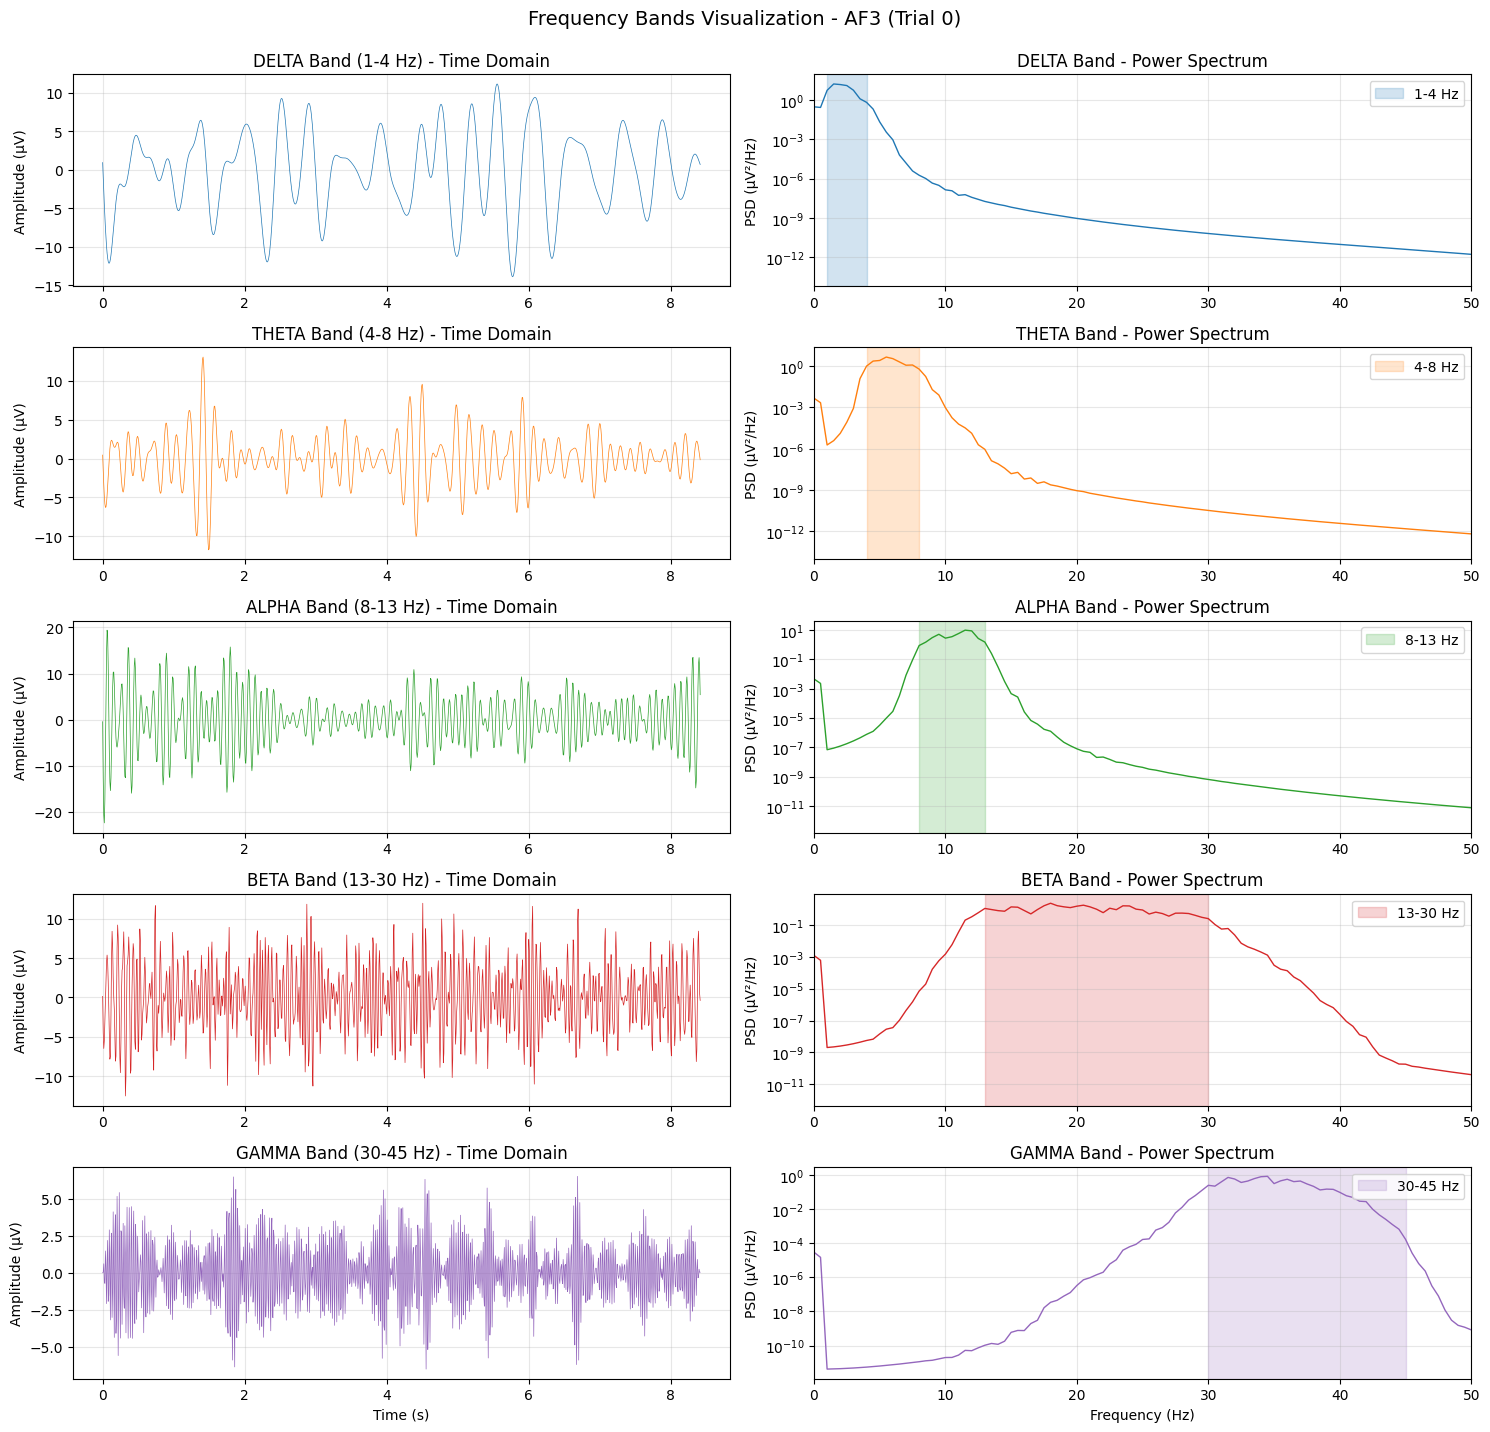


📊 Frequency Band Statistics (across all trials and channels):
------------------------------------------------------------
  DELTA : Mean= -0.0086, Std= 15.4096, Min=-1272.99, Max= 1291.10
  THETA : Mean= -0.0003, Std=  6.7141, Min= -744.64, Max=  753.12
  ALPHA : Mean= -0.0012, Std=  7.3466, Min= -563.52, Max=  560.23
  BETA  : Mean= -0.0007, Std=  5.0193, Min= -746.31, Max=  757.15
  GAMMA : Mean=  0.0000, Std=  2.5768, Min= -247.63, Max=  244.06
------------------------------------------------------------


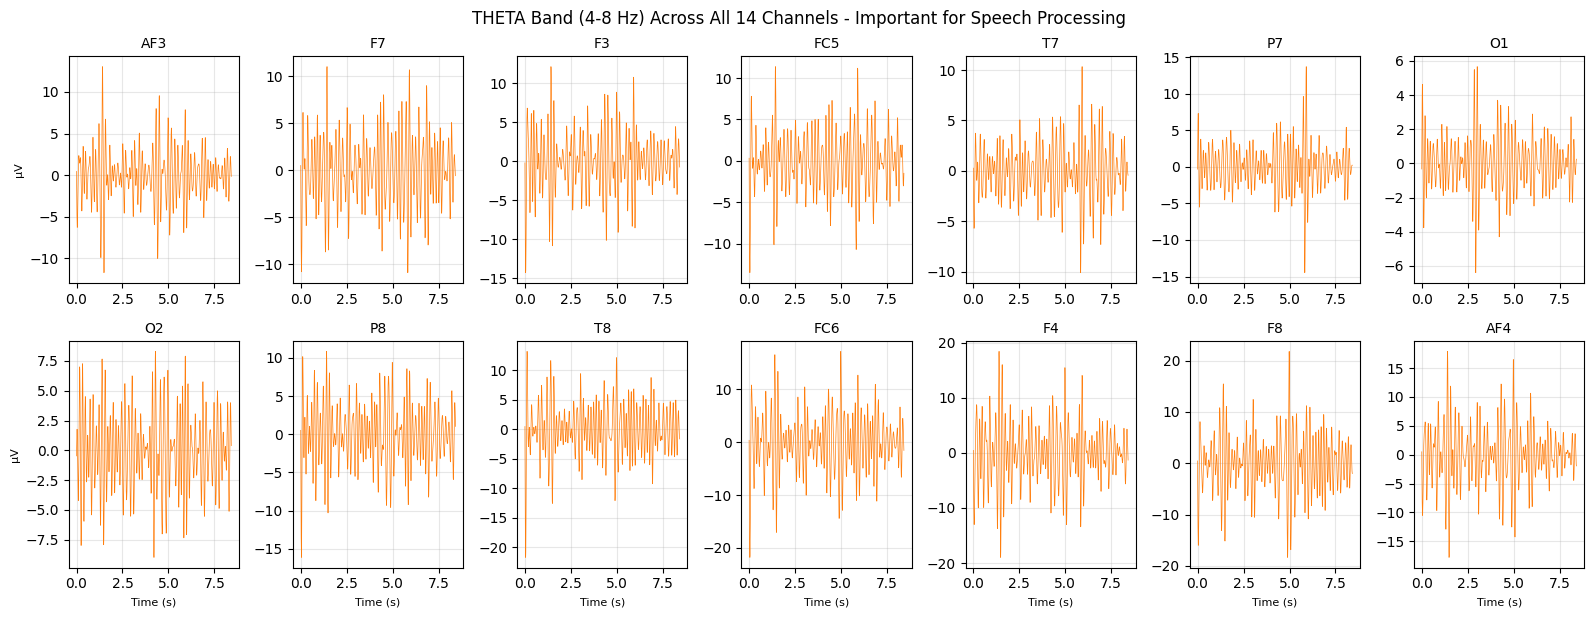


✓ Frequency bands visualization complete!


In [46]:
# Visualize extracted frequency bands
fig, axes = plt.subplots(5, 2, figsize=(15, 14))

# Select a sample trial and channel
sample_trial = 0
sample_channel = 0  # AF3
channel_name = channel_names[sample_channel] if 'channel_names' in dir(
) else EEG_CHANNELS[sample_channel].replace('EEG.', '')
time_axis = np.arange(X_filtered.shape[2]) / SFREQ

# Band colors
band_colors = {
    'delta': '#1f77b4',   # Blue
    'theta': '#ff7f0e',   # Orange
    'alpha': '#2ca02c',   # Green
    'beta': '#d62728',    # Red
    'gamma': '#9467bd'    # Purple
}

band_names = ['delta', 'theta', 'alpha', 'beta', 'gamma']
band_ranges = ['1-4 Hz', '4-8 Hz', '8-13 Hz', '13-30 Hz', '30-45 Hz']

for idx, (band_name, freq_range) in enumerate(zip(band_names, band_ranges)):
    ax_time = axes[idx, 0]
    ax_psd = axes[idx, 1]
    color = band_colors[band_name]

    # Time domain signal
    band_signal = band_data[band_name][sample_trial, sample_channel]
    ax_time.plot(time_axis, band_signal, linewidth=0.5, color=color)
    ax_time.set_ylabel('Amplitude (µV)')
    ax_time.set_title(f'{band_name.upper()} Band ({freq_range}) - Time Domain')
    ax_time.grid(True, alpha=0.3)
    if idx == 4:
        ax_time.set_xlabel('Time (s)')

    # Power Spectral Density
    freqs, psd = welch(band_signal, fs=SFREQ, nperseg=256)
    ax_psd.semilogy(freqs, psd, color=color, linewidth=1)
    ax_psd.set_xlim([0, 50])
    ax_psd.set_ylabel('PSD (µV²/Hz)')
    ax_psd.set_title(f'{band_name.upper()} Band - Power Spectrum')
    ax_psd.grid(True, alpha=0.3)

    # Mark the band's frequency range
    low, high = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (
        8, 13), 'beta': (13, 30), 'gamma': (30, 45)}[band_name]
    ax_psd.axvspan(low, high, alpha=0.2, color=color, label=f'{freq_range}')
    ax_psd.legend(loc='upper right')

    if idx == 4:
        ax_psd.set_xlabel('Frequency (Hz)')

plt.tight_layout()
plt.suptitle(
    f'Frequency Bands Visualization - {channel_name} (Trial {sample_trial})', fontsize=14, y=1.02)
plt.show()

# Summary statistics per band
print("\n📊 Frequency Band Statistics (across all trials and channels):")
print("-" * 60)
for band_name in band_names:
    band = band_data[band_name]
    print(f"  {band_name.upper():6s}: Mean={band.mean():8.4f}, Std={band.std():8.4f}, "
          f"Min={band.min():8.2f}, Max={band.max():8.2f}")
print("-" * 60)

# Multi-channel comparison for one band (theta - important for speech)
fig2, axes2 = plt.subplots(2, 7, figsize=(16, 6))
axes2 = axes2.flatten()

for ch_idx in range(14):
    ax = axes2[ch_idx]
    ch_name = EEG_CHANNELS[ch_idx].replace('EEG.', '')

    # Plot theta band for this channel
    theta_signal = band_data['theta'][sample_trial, ch_idx]
    ax.plot(time_axis, theta_signal, linewidth=0.5, color='#ff7f0e')
    ax.set_title(ch_name, fontsize=10)
    ax.grid(True, alpha=0.3)

    if ch_idx >= 7:
        ax.set_xlabel('Time (s)', fontsize=8)
    if ch_idx % 7 == 0:
        ax.set_ylabel('µV', fontsize=8)

plt.tight_layout()
plt.suptitle('THETA Band (4-8 Hz) Across All 14 Channels - Important for Speech Processing',
             fontsize=12, y=1.02)
plt.show()

print("\n✓ Frequency bands visualization complete!")

## Step 7: Epoching and Baseline Correction

Segment continuous EEG into overlapping epochs and apply baseline correction.

In [47]:
def epoch_data(X, y, participant_ids, epoch_duration=2.0, overlap=0.5, sfreq=SFREQ):
    """
    Segment continuous EEG into overlapping epochs.
    Critical for data augmentation in small datasets.

    Parameters:
    -----------
    X : np.ndarray
        EEG data with shape (trials, channels, timepoints)
    y : np.ndarray
        Labels for each trial
    participant_ids : np.ndarray
        Participant IDs for each trial
    epoch_duration : float
        Duration of each epoch in seconds
    overlap : float
        Overlap ratio between epochs (0-1)

    Returns:
    --------
    X_epoched : np.ndarray
        Epoched data with shape (n_epochs, channels, epoch_samples)
    y_epoched : np.ndarray
        Labels for each epoch
    participant_ids_epoched : np.ndarray
        Participant IDs for each epoch
    epoch_indices : list
        List of (trial, start_sample) tuples
    """
    epoch_samples = int(epoch_duration * sfreq)
    step = int(epoch_samples * (1 - overlap))

    n_trials, n_channels, n_times = X.shape
    n_epochs_per_trial = ((n_times - epoch_samples) // step) + 1

    X_epoched = np.zeros(
        (n_trials * n_epochs_per_trial, n_channels, epoch_samples))
    y_epoched = []
    participant_ids_epoched = []
    epoch_indices = []

    epoch_idx = 0
    for trial in range(n_trials):
        for start in range(0, n_times - epoch_samples + 1, step):
            X_epoched[epoch_idx] = X[trial, :, start:start + epoch_samples]
            y_epoched.append(y[trial])
            participant_ids_epoched.append(participant_ids[trial])
            epoch_indices.append((trial, start))
            epoch_idx += 1

    return X_epoched[:epoch_idx], np.array(y_epoched), np.array(participant_ids_epoched), epoch_indices


def baseline_correction(X, baseline_duration=0.5, sfreq=SFREQ):
    """
    Subtract pre-stimulus baseline.
    CRITICAL for evoked responses.

    Parameters:
    -----------
    X : np.ndarray
        EEG data with shape (trials, channels, timepoints)
    baseline_duration : float
        Duration of baseline period in seconds (from start of epoch)

    Returns:
    --------
    X_corrected : np.ndarray
        Baseline-corrected data
    """
    baseline_samples = int(baseline_duration * sfreq)

    # Use first baseline_samples as baseline
    baseline_mean = X[:, :, :baseline_samples].mean(axis=2, keepdims=True)
    X_corrected = X - baseline_mean

    return X_corrected


# Apply epoching
print("Epoching data...")
epoch_duration = 2.0  # seconds
overlap = 0.5  # 50% overlap

X_epoched, y_epoched, participant_ids_epoched, epoch_indices = epoch_data(
    X_filtered, y, participant_ids,
    epoch_duration=epoch_duration,
    overlap=overlap
)

print(f"✓ Epoching complete!")
print(
    f"  Original: {X_filtered.shape[0]} trials × {X_filtered.shape[2]} timepoints")
print(
    f"  Epoched:  {X_epoched.shape[0]} epochs × {X_epoched.shape[2]} timepoints")
print(
    f"  Epoch duration: {epoch_duration}s ({int(epoch_duration * SFREQ)} samples)")
print(f"  Overlap: {overlap*100:.0f}%")

# Apply baseline correction
print("\nApplying baseline correction...")
baseline_duration = 0.5  # seconds
X_corrected = baseline_correction(
    X_epoched, baseline_duration=baseline_duration)

print(f"✓ Baseline correction complete!")
print(
    f"  Baseline duration: {baseline_duration}s ({int(baseline_duration * SFREQ)} samples)")
print(f"  Before correction - Mean: {X_epoched.mean():.4f}")
print(f"  After correction  - Mean: {X_corrected.mean():.4f}")

print(f"\n{'='*60}")
print("FINAL DATA SHAPES:")
print(f"  X_corrected: {X_corrected.shape} (epochs, channels, timepoints)")
print(f"  y_epoched: {y_epoched.shape}")
print(f"  participant_ids_epoched: {participant_ids_epoched.shape}")
print(f"{'='*60}")

Epoching data...
✓ Epoching complete!
  Original: 346 trials × 1078 timepoints
  Epoched:  2422 epochs × 256 timepoints
  Epoch duration: 2.0s (256 samples)
  Overlap: 50%

Applying baseline correction...
✓ Baseline correction complete!
  Baseline duration: 0.5s (64 samples)
  Before correction - Mean: -0.0139
  After correction  - Mean: -0.0121

FINAL DATA SHAPES:
  X_corrected: (2422, 14, 256) (epochs, channels, timepoints)
  y_epoched: (2422,)
  participant_ids_epoched: (2422,)


## Step 8: Data Summary and Visualization

Visualize the preprocessed EEG data.

In [48]:
# Print data summary
print("="*70)
print("PREPROCESSED DATA SUMMARY")
print("="*70)

print(f"\n📊 Final Data Arrays:")
print(f"  X_corrected shape: {X_corrected.shape}")
print(f"    - {X_corrected.shape[0]} epochs")
print(f"    - {X_corrected.shape[1]} channels")
print(
    f"    - {X_corrected.shape[2]} timepoints ({X_corrected.shape[2]/SFREQ:.2f}s)")

print(f"\n  y_epoched shape: {y_epoched.shape}")
print(f"    - {len(np.unique(y_epoched))} unique classes")

print(f"\n  participant_ids_epoched shape: {participant_ids_epoched.shape}")
print(f"    - {len(np.unique(participant_ids_epoched))} unique participants")

print(f"\n📈 Data Statistics:")
print(f"  Mean: {X_corrected.mean():.4f} µV")
print(f"  Std:  {X_corrected.std():.4f} µV")
print(f"  Min:  {X_corrected.min():.4f} µV")
print(f"  Max:  {X_corrected.max():.4f} µV")

print(f"\n🏷️ Class Distribution:")
unique_labels, label_counts = np.unique(y_epoched, return_counts=True)
for label, count in zip(unique_labels, label_counts):
    word = [w for w, l in word_to_label.items() if l == label][0]
    print(f"  Class {label:2d} ({word}): {count} epochs")

print(f"\n👥 Participant Distribution:")
unique_pids, pid_counts = np.unique(
    participant_ids_epoched, return_counts=True)
for pid, count in zip(unique_pids, pid_counts):
    print(f"  Participant {pid:2d}: {count} epochs")

print("="*70)

PREPROCESSED DATA SUMMARY

📊 Final Data Arrays:
  X_corrected shape: (2422, 14, 256)
    - 2422 epochs
    - 14 channels
    - 256 timepoints (2.00s)

  y_epoched shape: (2422,)
    - 16 unique classes

  participant_ids_epoched shape: (2422,)
    - 25 unique participants

📈 Data Statistics:
  Mean: -0.0121 µV
  Std:  21.4960 µV
  Min:  -2031.4112 µV
  Max:  1825.7214 µV

🏷️ Class Distribution:
  Class  0 (اختر): 154 epochs
  Class  1 (اسفل): 147 epochs
  Class  2 (اعلى): 154 epochs
  Class  3 (انذار): 154 epochs
  Class  4 (ايقاف تشغيل): 147 epochs
  Class  5 (تشغيل): 154 epochs
  Class  6 (جوع): 147 epochs
  Class  7 (حذف): 147 epochs
  Class  8 (حمام): 154 epochs
  Class  9 (دواء): 154 epochs
  Class 10 (عطش): 154 epochs
  Class 11 (لا): 154 epochs
  Class 12 (مسافة): 140 epochs
  Class 13 (نعم): 154 epochs
  Class 14 (يسار): 154 epochs
  Class 15 (يمين): 154 epochs

👥 Participant Distribution:
  Participant  1: 105 epochs
  Participant  2: 112 epochs
  Participant  3: 112 epochs
  

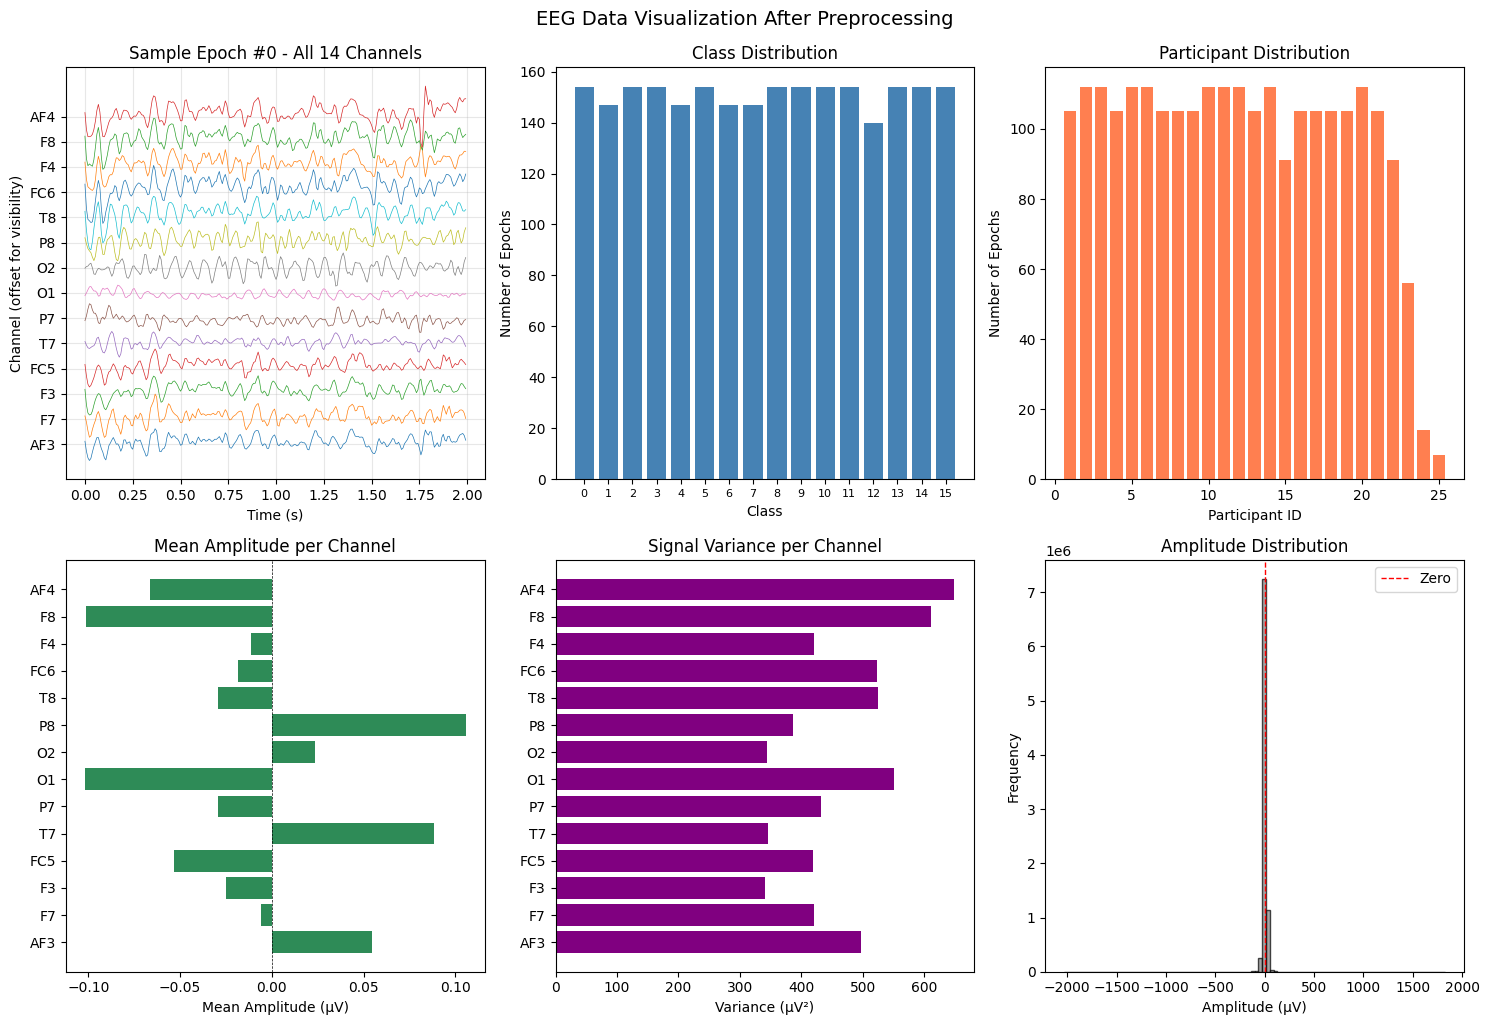

✓ Visualization complete!


In [49]:
# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Channel names without 'EEG.' prefix
channel_names = [ch.replace('EEG.', '') for ch in EEG_CHANNELS]

# 1. Sample epoch - all channels
ax1 = axes[0, 0]
sample_epoch_idx = 0
time_axis = np.arange(X_corrected.shape[2]) / SFREQ
for ch_idx in range(X_corrected.shape[1]):
    ax1.plot(time_axis, X_corrected[sample_epoch_idx, ch_idx] + ch_idx * 50,
             linewidth=0.5, label=channel_names[ch_idx])
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Channel (offset for visibility)')
ax1.set_title(f'Sample Epoch #{sample_epoch_idx} - All 14 Channels')
ax1.set_yticks(np.arange(14) * 50)
ax1.set_yticklabels(channel_names)
ax1.grid(True, alpha=0.3)

# 2. Class distribution bar plot
ax2 = axes[0, 1]
word_names = [w for w, _ in sorted(word_to_label.items(), key=lambda x: x[1])]
ax2.bar(range(len(label_counts)), label_counts, color='steelblue')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Epochs')
ax2.set_title('Class Distribution')
ax2.set_xticks(range(len(label_counts)))
ax2.set_xticklabels(range(len(label_counts)), fontsize=8)

# 3. Participant distribution
ax3 = axes[0, 2]
ax3.bar(unique_pids, pid_counts, color='coral')
ax3.set_xlabel('Participant ID')
ax3.set_ylabel('Number of Epochs')
ax3.set_title('Participant Distribution')

# 4. Mean signal per channel
ax4 = axes[1, 0]
mean_per_channel = X_corrected.mean(axis=(0, 2))
ax4.barh(range(14), mean_per_channel, color='seagreen')
ax4.set_yticks(range(14))
ax4.set_yticklabels(channel_names)
ax4.set_xlabel('Mean Amplitude (µV)')
ax4.set_title('Mean Amplitude per Channel')
ax4.axvline(x=0, color='black', linestyle='--', linewidth=0.5)

# 5. Signal variance per channel
ax5 = axes[1, 1]
var_per_channel = X_corrected.var(axis=(0, 2))
ax5.barh(range(14), var_per_channel, color='purple')
ax5.set_yticks(range(14))
ax5.set_yticklabels(channel_names)
ax5.set_xlabel('Variance (µV²)')
ax5.set_title('Signal Variance per Channel')

# 6. Histogram of all values
ax6 = axes[1, 2]
ax6.hist(X_corrected.flatten(), bins=100,
         color='gray', edgecolor='black', alpha=0.7)
ax6.set_xlabel('Amplitude (µV)')
ax6.set_ylabel('Frequency')
ax6.set_title('Amplitude Distribution')
ax6.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero')
ax6.legend()

plt.tight_layout()
plt.suptitle('EEG Data Visualization After Preprocessing', fontsize=14, y=1.02)
plt.show()

print("✓ Visualization complete!")

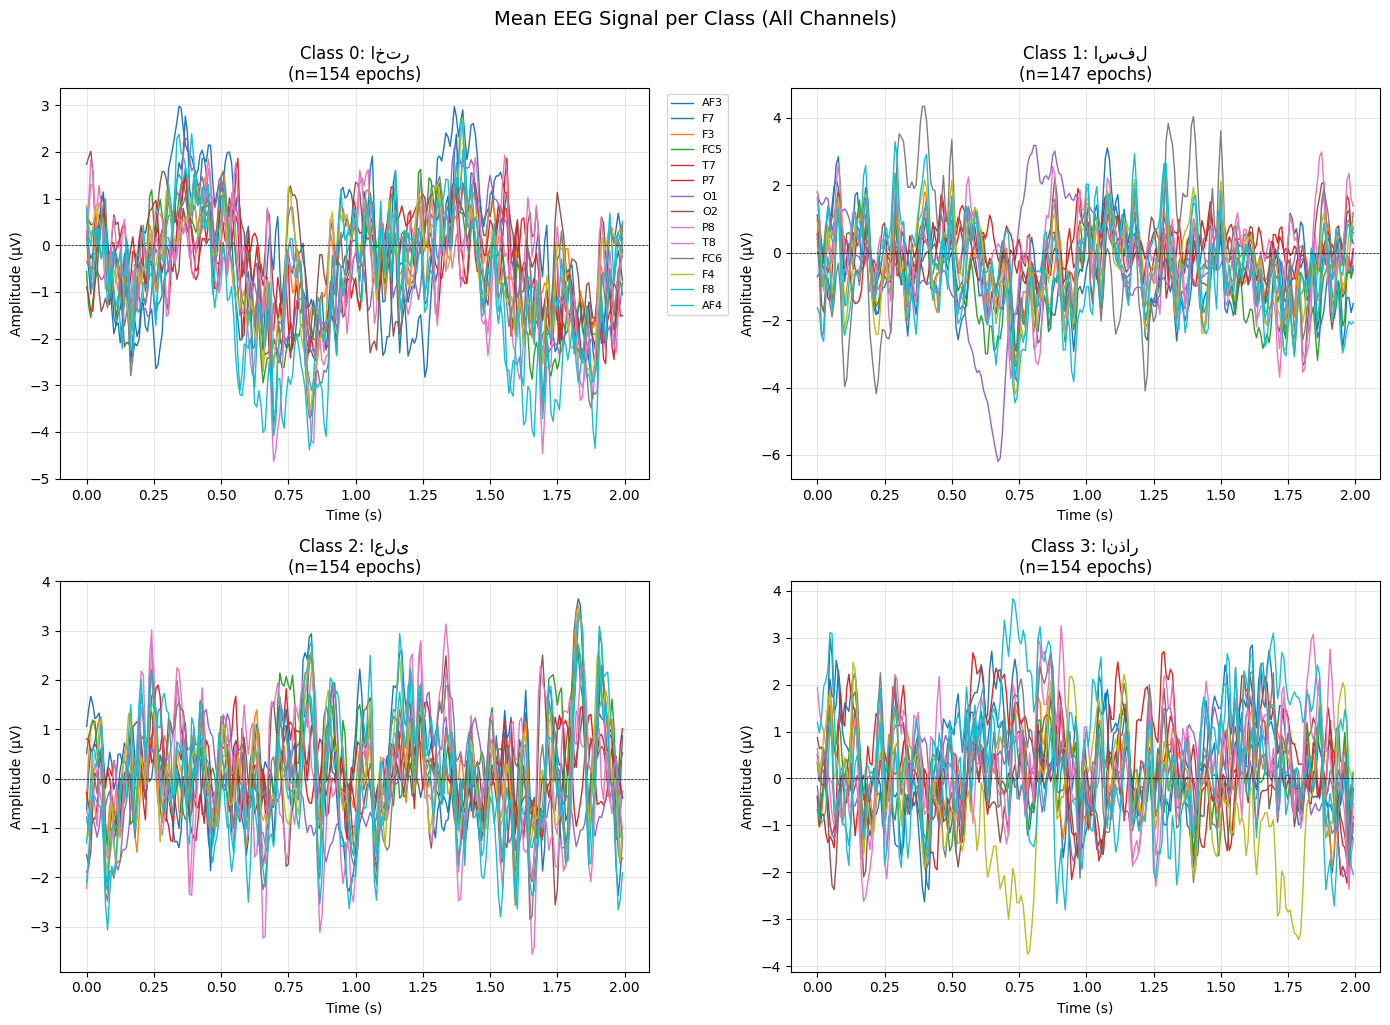

✓ Class comparison visualization complete!


In [50]:
# Compare average signals across different classes (first 4 classes)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

time_axis = np.arange(X_corrected.shape[2]) / SFREQ
colors = plt.cm.tab10(np.linspace(0, 1, 14))

for plot_idx, class_idx in enumerate(range(min(4, len(unique_labels)))):
    ax = axes[plot_idx]

    # Get epochs for this class
    class_mask = y_epoched == class_idx
    class_data = X_corrected[class_mask]

    # Plot mean signal for each channel
    mean_signal = class_data.mean(axis=0)

    for ch_idx in range(14):
        ax.plot(time_axis, mean_signal[ch_idx],
                color=colors[ch_idx], linewidth=1,
                label=channel_names[ch_idx] if plot_idx == 0 else None)

    word = [w for w, l in word_to_label.items() if l == class_idx][0]
    ax.set_title(f'Class {class_idx}: {word}\n(n={class_mask.sum()} epochs)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (µV)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)

# Add legend to first plot
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.suptitle('Mean EEG Signal per Class (All Channels)', fontsize=14, y=1.02)
plt.show()

print("✓ Class comparison visualization complete!")

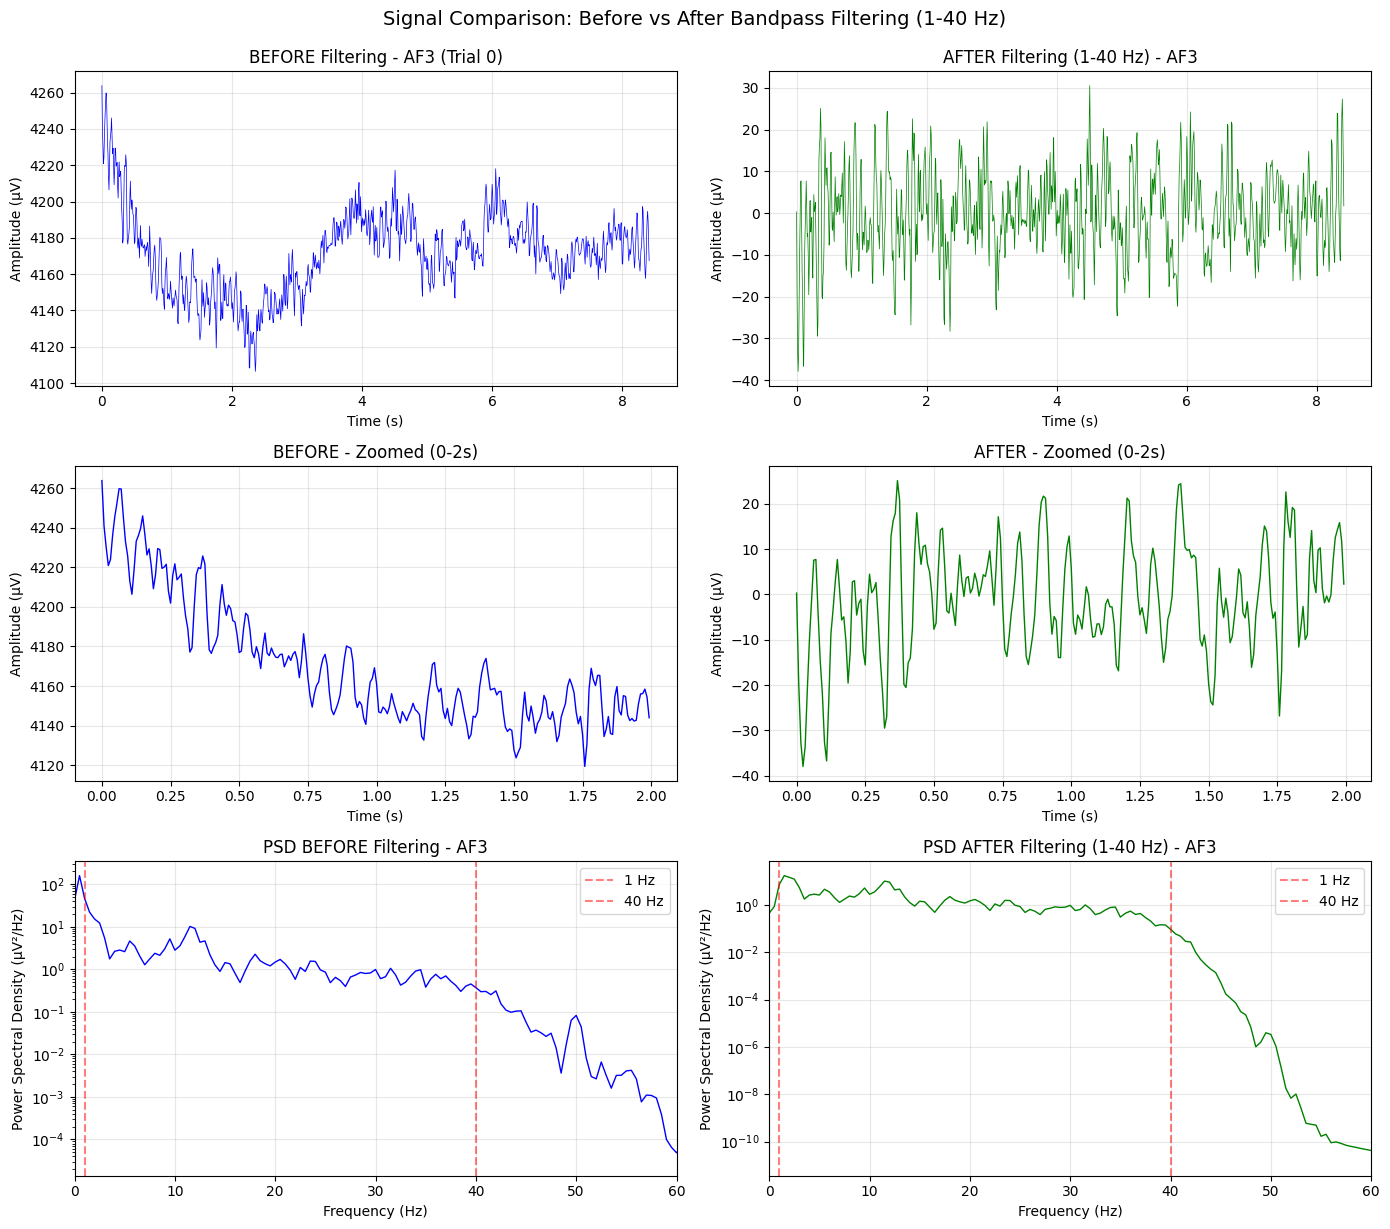


📊 Filtering Statistics:
  BEFORE - Mean: 4171.48, Std: 22.39
  AFTER  - Mean: -0.21, Std: 9.85

✓ DC offset removed: 4171.27 µV


In [51]:
# Compare signals before and after filtering
from scipy.signal import welch
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Select a sample trial and channel
sample_trial = 0
sample_channel = 0  # AF3
channel_name = channel_names[sample_channel]
time_axis_full = np.arange(X.shape[2]) / SFREQ

# Row 1: Full signal comparison
ax1, ax2 = axes[0, 0], axes[0, 1]

ax1.plot(time_axis_full, X[sample_trial,
         sample_channel], linewidth=0.5, color='blue')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (µV)')
ax1.set_title(f'BEFORE Filtering - {channel_name} (Trial {sample_trial})')
ax1.grid(True, alpha=0.3)

ax2.plot(time_axis_full, X_filtered[sample_trial,
         sample_channel], linewidth=0.5, color='green')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (µV)')
ax2.set_title(f'AFTER Filtering (1-40 Hz) - {channel_name}')
ax2.grid(True, alpha=0.3)

# Row 2: Zoomed view (first 2 seconds)
ax3, ax4 = axes[1, 0], axes[1, 1]
zoom_samples = int(2 * SFREQ)
time_zoom = np.arange(zoom_samples) / SFREQ

ax3.plot(time_zoom, X[sample_trial, sample_channel,
         :zoom_samples], linewidth=1, color='blue')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Amplitude (µV)')
ax3.set_title(f'BEFORE - Zoomed (0-2s)')
ax3.grid(True, alpha=0.3)

ax4.plot(time_zoom, X_filtered[sample_trial, sample_channel,
         :zoom_samples], linewidth=1, color='green')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Amplitude (µV)')
ax4.set_title(f'AFTER - Zoomed (0-2s)')
ax4.grid(True, alpha=0.3)

# Row 3: Power Spectral Density comparison

ax5, ax6 = axes[2, 0], axes[2, 1]

# PSD before filtering
freqs_before, psd_before = welch(
    X[sample_trial, sample_channel], fs=SFREQ, nperseg=256)
ax5.semilogy(freqs_before, psd_before, color='blue', linewidth=1)
ax5.set_xlabel('Frequency (Hz)')
ax5.set_ylabel('Power Spectral Density (µV²/Hz)')
ax5.set_title(f'PSD BEFORE Filtering - {channel_name}')
ax5.set_xlim([0, 60])
ax5.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='1 Hz')
ax5.axvline(x=40, color='red', linestyle='--', alpha=0.5, label='40 Hz')
ax5.grid(True, alpha=0.3)
ax5.legend()

# PSD after filtering
freqs_after, psd_after = welch(
    X_filtered[sample_trial, sample_channel], fs=SFREQ, nperseg=256)
ax6.semilogy(freqs_after, psd_after, color='green', linewidth=1)
ax6.set_xlabel('Frequency (Hz)')
ax6.set_ylabel('Power Spectral Density (µV²/Hz)')
ax6.set_title(f'PSD AFTER Filtering (1-40 Hz) - {channel_name}')
ax6.set_xlim([0, 60])
ax6.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='1 Hz')
ax6.axvline(x=40, color='red', linestyle='--', alpha=0.5, label='40 Hz')
ax6.grid(True, alpha=0.3)
ax6.legend()

plt.tight_layout()
plt.suptitle(
    'Signal Comparison: Before vs After Bandpass Filtering (1-40 Hz)', fontsize=14, y=1.02)
plt.show()

# Print statistics
print("\n📊 Filtering Statistics:")
print(
    f"  BEFORE - Mean: {X[sample_trial, sample_channel].mean():.2f}, Std: {X[sample_trial, sample_channel].std():.2f}")
print(
    f"  AFTER  - Mean: {X_filtered[sample_trial, sample_channel].mean():.2f}, Std: {X_filtered[sample_trial, sample_channel].std():.2f}")
print(
    f"\n✓ DC offset removed: {abs(X[sample_trial, sample_channel].mean()) - abs(X_filtered[sample_trial, sample_channel].mean()):.2f} µV")

## Step 9: Per-Participant Model Training

Train a separate model for each participant (subject-dependent approach).
Each participant has 16 words → 16-class classification per participant.

**Strategy**: Train individual models, then explore generalization approaches.

In [52]:
# Import PyTorch and additional libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
from tqdm.notebook import tqdm

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✓ PyTorch libraries imported")
print(f"  PyTorch version: {torch.__version__}")
print(f"  CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
print(f"  Using device: {device}")

✓ PyTorch libraries imported
  PyTorch version: 2.0.1+cpu
  CUDA available: False
  Using device: cpu


In [53]:
# ============================================================================
# MODEL HYPERPARAMETERS
# ============================================================================

# Get data dimensions from preprocessed data
N_CLASSES = len(word_to_label)
N_CHANNELS = X_corrected.shape[1]  # 14 channels
N_TIMEPOINTS = X_corrected.shape[2]  # samples per epoch

# Convolutional feature extraction (EEGNet-inspired)
F1 = 8           # Temporal filters
K1 = 64          # Temporal kernel size
F2 = 16          # Spatial filters per temporal filter
K2 = 16          # Separable kernel size

# Temporal Convolutional Network (TCN)
TCN_CHANNELS = [32, 64, 128]  # 3 residual blocks
TCN_KERNEL = 4                # Kernel size for TCN

# Transformer
NUM_TRANSFORMER_BLOCKS = 6    # Number of transformer blocks
NUM_HEADS = 8                 # Multi-head attention heads
DROPOUT = 0.3                 # Dropout rate

# Training parameters
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
PATIENCE = 20                 # Early stopping patience

# Regularization
LABEL_SMOOTHING = 0.1
WEIGHT_DECAY = 1e-4
GRADIENT_CLIP = 1.0

# Data augmentation & balancing
USE_CLASS_WEIGHTS = True
USE_MIXUP = True
MIXUP_ALPHA = 0.2

print("="*70)
print("MODEL CONFIGURATION")
print("="*70)
print(f"\nInput Data:")
print(f"  Shape: {X_corrected.shape}")
print(f"  Channels: {N_CHANNELS}")
print(f"  Timepoints: {N_TIMEPOINTS} ({N_TIMEPOINTS/SFREQ:.2f}s)")
print(f"  Classes: {N_CLASSES}")
print(f"\nModel Architecture:")
print(f"  EEGNet: F1={F1}, K1={K1}, F2={F2}, K2={K2}")
print(f"  TCN blocks: {len(TCN_CHANNELS)} ({TCN_CHANNELS})")
print(f"  Transformer blocks: {NUM_TRANSFORMER_BLOCKS}")
print(f"  Attention heads: {NUM_HEADS}")
print(f"  Dropout: {DROPOUT}")
print(f"\nTraining:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Max epochs: {NUM_EPOCHS}")
print(f"  Early stopping patience: {PATIENCE}")
print(f"  Device: {device}")
print("="*70)

MODEL CONFIGURATION

Input Data:
  Shape: (2422, 14, 256)
  Channels: 14
  Timepoints: 256 (2.00s)
  Classes: 16

Model Architecture:
  EEGNet: F1=8, K1=64, F2=16, K2=16
  TCN blocks: 3 ([32, 64, 128])
  Transformer blocks: 6
  Attention heads: 8
  Dropout: 0.3

Training:
  Batch size: 32
  Learning rate: 0.001
  Max epochs: 100
  Early stopping patience: 20
  Device: cpu


In [54]:
# ============================================================================
# MODEL ARCHITECTURE: EEG-TCNTransformer
# ============================================================================

class ResidualBlock(nn.Module):
    """Residual block for TCN with dilated causal convolutions."""

    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.3):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=self.padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.dropout1 = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=self.padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout2 = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(
            in_channels, out_channels, 1) if in_channels != out_channels else None
        self.elu = nn.ELU()

    def forward(self, x):
        out = self.elu(self.bn1(self.conv1(x)[:, :, :-self.padding]))
        out = self.dropout1(out)
        out = self.elu(self.bn2(self.conv2(out)[:, :, :-self.padding]))
        out = self.dropout2(out)
        if self.downsample:
            x = self.downsample(x)
        if x.size(2) != out.size(2):
            x = x[:, :, :out.size(2)]
        return self.elu(out + x)


class TemporalConvNet(nn.Module):
    """Temporal Convolutional Network with exponentially increasing dilation."""

    def __init__(self, num_inputs, num_channels, kernel_size=4, dropout=0.3):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            in_ch = num_inputs if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            dilation = 2 ** i
            layers.append(ResidualBlock(
                in_ch, out_ch, kernel_size, dilation, dropout))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


class MultiHeadSelfAttention(nn.Module):
    """Multi-head self-attention mechanism."""

    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv_proj = nn.Linear(embed_dim, 3 * embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5

    def forward(self, x):
        B, L, D = x.shape
        qkv = self.qkv_proj(x).reshape(
            B, L, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = self.dropout(F.softmax(torch.matmul(
            q, k.transpose(-2, -1)) * self.scale, dim=-1))
        return self.out_proj(torch.matmul(attn, v).transpose(1, 2).reshape(B, L, D))


class TransformerBlock(nn.Module):
    """Transformer encoder block with multi-head attention and feedforward network."""

    def __init__(self, embed_dim, num_heads=8, ff_dim=512, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.norm1(x + self.dropout1(self.attention(x)))
        return self.norm2(x + self.ff(x))


class EEGTCNTransformer(nn.Module):
    """
    EEG-TCNTransformer: Hybrid architecture combining:
    1. EEGNet-style spatial-temporal convolutions
    2. Temporal Convolutional Network (TCN) for long-range dependencies
    3. Transformer encoder for global context modeling
    """

    def __init__(self, n_classes, n_channels, n_timepoints,
                 F1=8, K1=64, F2=16, K2=16,
                 tcn_channels=[32, 64, 128], tcn_kernel=4,
                 num_transformer_blocks=6, num_heads=8, dropout=0.3):
        super().__init__()

        # EEGNet-style feature extraction
        self.temporal_conv = nn.Sequential(
            nn.Conv2d(1, F1, (1, K1), padding=(0, K1//2), bias=False),
            nn.BatchNorm2d(F1)
        )
        self.spatial_conv = nn.Sequential(
            nn.Conv2d(F1, F1 * F2, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * F2),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout)
        )
        self.separable_conv = nn.Sequential(
            nn.Conv2d(F1 * F2, F1 * F2, (1, K2), padding=(0, K2//2),
                      groups=F1 * F2, bias=False),
            nn.Conv2d(F1 * F2, F1 * F2, (1, 1), bias=False),
            nn.BatchNorm2d(F1 * F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout)
        )

        # TCN for temporal modeling
        self.tcn = TemporalConvNet(F1 * F2, tcn_channels, tcn_kernel, dropout)

        # Transformer
        self.embed_dim = tcn_channels[-1]
        self.pos_encoding = nn.Parameter(torch.randn(
            1, n_timepoints // 32, self.embed_dim) * 0.02)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(self.embed_dim, num_heads,
                             self.embed_dim * 4, dropout)
            for _ in range(num_transformer_blocks)
        ])

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.embed_dim, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # Add channel dimension: (B, C, T) -> (B, 1, C, T)
        x = x.unsqueeze(1)

        # EEGNet feature extraction
        x = self.temporal_conv(x)
        x = self.spatial_conv(x)
        x = self.separable_conv(x)

        # Remove spatial dimension: (B, F, 1, T') -> (B, F, T')
        x = x.squeeze(2)

        # TCN
        x = self.tcn(x)

        # Prepare for transformer: (B, F, T') -> (B, T', F)
        x = x.transpose(1, 2)

        # Add positional encoding
        if x.size(1) <= self.pos_encoding.size(1):
            x = x + self.pos_encoding[:, :x.size(1), :]

        # Transformer blocks
        for block in self.transformer_blocks:
            x = block(x)

        # Global average pooling and classification
        x = x.mean(dim=1)
        return self.classifier(x)


# Create model
model = EEGTCNTransformer(
    n_classes=N_CLASSES,
    n_channels=N_CHANNELS,
    n_timepoints=N_TIMEPOINTS,
    F1=F1, K1=K1, F2=F2, K2=K2,
    tcn_channels=TCN_CHANNELS,
    tcn_kernel=TCN_KERNEL,
    num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
).to(device)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel()
                       for p in model.parameters() if p.requires_grad)

print("="*70)
print("EEG-TCNTransformer MODEL")
print("="*70)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nModel architecture:")
print(model)
print("="*70)

EEG-TCNTransformer MODEL

Total parameters: 1,396,992
Trainable parameters: 1,396,992

Model architecture:
EEGTCNTransformer(
  (temporal_conv): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (spatial_conv): Sequential(
    (0): Conv2d(8, 128, kernel_size=(14, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.3, inplace=False)
  )
  (separable_conv): Sequential(
    (0): Conv2d(128, 128, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=128, bias=False)
    (1): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): 

In [55]:
# ============================================================================
# PER-PARTICIPANT DATA ORGANIZATION
# ============================================================================

class EEGDataset(Dataset):
    """PyTorch Dataset for EEG data."""

    def __init__(self, data, labels):
        self.data = torch.FloatTensor(data)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


# Get unique participants
unique_participants = np.unique(participant_ids_epoched)
n_participants = len(unique_participants)

print("="*70)
print("PER-PARTICIPANT DATA ORGANIZATION")
print("="*70)
print(f"\nTotal epochs: {len(X_corrected)}")
print(f"Total participants: {n_participants}")
print(f"Classes per participant: {N_CLASSES}")

# Organize data by participant
participant_data = {}

for pid in unique_participants:
    mask = participant_ids_epoched == pid
    X_pid = X_corrected[mask]
    y_pid = y_epoched[mask]

    participant_data[pid] = {
        'X': X_pid,
        'y': y_pid,
        'n_epochs': len(X_pid),
        'n_classes': len(np.unique(y_pid))
    }

print(f"\n{'Participant':<12} {'Epochs':<10} {'Classes':<10}")
print("-"*35)
for pid, data in participant_data.items():
    print(f"{pid:<12} {data['n_epochs']:<10} {data['n_classes']:<10}")

print("-"*35)
print(f"{'Total':<12} {len(X_corrected):<10}")
print("="*70)

PER-PARTICIPANT DATA ORGANIZATION

Total epochs: 2422
Total participants: 25
Classes per participant: 16

Participant  Epochs     Classes   
-----------------------------------
1            105        15        
2            112        16        
3            112        16        
4            105        15        
5            112        16        
6            112        16        
7            105        15        
8            105        15        
9            105        15        
10           112        16        
11           112        16        
12           112        16        
13           105        15        
14           112        16        
15           91         13        
16           105        15        
17           105        15        
18           105        15        
19           105        15        
20           112        16        
21           105        15        
22           91         13        
23           56         8         
24           14   

In [56]:
# ============================================================================
# TRAINING FUNCTIONS (Per-Participant)
# ============================================================================

def create_model():
    """Create a fresh model instance."""
    return EEGTCNTransformer(
        n_classes=N_CLASSES,
        n_channels=N_CHANNELS,
        n_timepoints=N_TIMEPOINTS,
        F1=F1, K1=K1, F2=F2, K2=K2,
        tcn_channels=TCN_CHANNELS,
        tcn_kernel=TCN_KERNEL,
        num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
        num_heads=NUM_HEADS,
        dropout=DROPOUT
    ).to(device)


def mixup_data(x, y, alpha=0.2):
    """Apply mixup augmentation."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[index], y, y[index], lam


def train_epoch(model, loader, criterion, optimizer, use_mixup=True):
    """Train for one epoch."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        if use_mixup and np.random.rand() > 0.5:
            inputs, labels_a, labels_b, lam = mixup_data(
                inputs, labels, MIXUP_ALPHA)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = lam * criterion(outputs, labels_a) + \
                (1 - lam) * criterion(outputs, labels_b)
        else:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        loss.backward()
        if GRADIENT_CLIP > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total


def validate(model, loader, criterion):
    """Validate the model."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total


def train_participant_model(pid, X_data, y_data, epochs=50, patience=10, verbose=True):
    """
    Train a model for a single participant.
    Splits their data into 80% train / 20% test.
    """
    # Split data for this participant (80/20)
    indices = np.arange(len(X_data))
    np.random.shuffle(indices)
    split_idx = int(0.8 * len(indices))

    train_idx = indices[:split_idx]
    test_idx = indices[split_idx:]

    X_train, y_train = X_data[train_idx], y_data[train_idx]
    X_test, y_test = X_data[test_idx], y_data[test_idx]

    # Create datasets and loaders
    train_dataset = EEGDataset(X_train, y_train)
    test_dataset = EEGDataset(X_test, y_test)

    # Class weights
    class_counts = np.bincount(y_train, minlength=N_CLASSES)
    class_counts = np.maximum(class_counts, 1)  # Avoid division by zero
    class_weights = torch.FloatTensor(
        1.0 / class_counts / (1.0 / class_counts).sum() * len(class_counts)
    ).to(device)

    train_loader = DataLoader(train_dataset, batch_size=min(
        BATCH_SIZE, len(train_dataset)), shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=min(
        BATCH_SIZE, len(test_dataset)), shuffle=False)

    # Create fresh model
    model = create_model()
    criterion = nn.CrossEntropyLoss(
        weight=class_weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6)

    # Training loop
    best_acc = 0.0
    patience_counter = 0
    history = {'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, use_mixup=USE_MIXUP)
        test_loss, test_acc = validate(model, test_loader, criterion)
        scheduler.step()

        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            patience_counter = 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    # Load best model state
    model.load_state_dict(best_state)

    return model, best_acc, history, len(X_train), len(X_test)


print("✓ Per-participant training functions defined")
print(f"  Model factory: create_model()")
print(f"  Training: train_participant_model()")
print(f"  Per-participant split: 80% train / 20% test")

✓ Per-participant training functions defined
  Model factory: create_model()
  Training: train_participant_model()
  Per-participant split: 80% train / 20% test


In [57]:
# ============================================================================
# TRAIN INDIVIDUAL MODELS FOR EACH PARTICIPANT
# ============================================================================

import os
print("="*70)
print("TRAINING INDIVIDUAL MODELS PER PARTICIPANT")
print("="*70)
print(f"Device: {device}")
print(f"Epochs per participant: {NUM_EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")
print("-"*70)

# Store results and models
participant_models = {}
participant_results = {}

# Create models directory
os.makedirs('participant_models', exist_ok=True)

for i, pid in enumerate(unique_participants):
    print(f"\n[{i+1}/{n_participants}] Training model for Participant {pid}...")

    X_pid = participant_data[pid]['X']
    y_pid = participant_data[pid]['y']

    # Train model for this participant
    model, best_acc, history, n_train, n_test = train_participant_model(
        pid, X_pid, y_pid,
        epochs=NUM_EPOCHS,
        patience=PATIENCE,
        verbose=False
    )

    # Save model
    model_path = f'participant_models/model_participant_{pid}.pth'
    torch.save(model.state_dict(), model_path)

    # Store results
    participant_models[pid] = model
    participant_results[pid] = {
        'best_accuracy': best_acc,
        'n_train': n_train,
        'n_test': n_test,
        'n_epochs': len(history['train_acc']),
        'history': history
    }

    print(
        f"    ✓ Best Accuracy: {best_acc:.2f}% | Train: {n_train}, Test: {n_test} | Epochs: {len(history['train_acc'])}")

print("\n" + "-"*70)
print("✓ All participant models trained!")
print(f"  Models saved to: participant_models/")
print("="*70)

TRAINING INDIVIDUAL MODELS PER PARTICIPANT
Device: cpu
Epochs per participant: 100
Early stopping patience: 20
----------------------------------------------------------------------

[1/25] Training model for Participant 1...
    ✓ Best Accuracy: 14.29% | Train: 84, Test: 21 | Epochs: 25

[2/25] Training model for Participant 2...
    ✓ Best Accuracy: 30.43% | Train: 89, Test: 23 | Epochs: 55

[3/25] Training model for Participant 3...
    ✓ Best Accuracy: 26.09% | Train: 89, Test: 23 | Epochs: 62

[4/25] Training model for Participant 4...
    ✓ Best Accuracy: 28.57% | Train: 84, Test: 21 | Epochs: 34

[5/25] Training model for Participant 5...
    ✓ Best Accuracy: 47.83% | Train: 89, Test: 23 | Epochs: 78

[6/25] Training model for Participant 6...
    ✓ Best Accuracy: 60.87% | Train: 89, Test: 23 | Epochs: 94

[7/25] Training model for Participant 7...
    ✓ Best Accuracy: 33.33% | Train: 84, Test: 21 | Epochs: 60

[8/25] Training model for Participant 8...
    ✓ Best Accuracy: 28.5

In [ ]:
# ============================================================================
# PER-PARTICIPANT RESULTS SUMMARY
# ============================================================================

print("="*70)
print("PER-PARTICIPANT MODEL RESULTS")
print("="*70)

# Extract accuracies
accuracies = [participant_results[pid]['best_accuracy']
              for pid in unique_participants]

print(f"\n{'Participant':<12} {'Accuracy':<12} {'N_Train':<10} {'N_Test':<10} {'Stopped at Epoch':<18}")
print("-"*70)

for pid in sorted(unique_participants):
    res = participant_results[pid]
    print(
        f"{pid:<12} {res['best_accuracy']:>8.2f}%   {res['n_train']:<10} {res['n_test']:<10} {res['n_epochs']:<18}")

print("-"*70)
print(f"\nℹ️ NOTE ON TRAINING EPOCHS:")
print("The 'Stopped at Epoch' count varies because of EARLY STOPPING.")
print(f"- Patience: {PATIENCE} epochs without improvement")
print("- Max Epochs: {NUM_EPOCHS}")
print("- Models that learn clearly stop earlier.")
print("- Models struggling with noise may run longer or stop early if loss plateaus.")

print(f"\n📊 STATISTICS:")
print(f"  Mean Accuracy:   {np.mean(accuracies):.2f}%")
print(f"  Std Accuracy:    {np.std(accuracies):.2f}%")
print(f"  Min Accuracy:    {np.min(accuracies):.2f}%")
print(f"  Max Accuracy:    {np.max(accuracies):.2f}%")
print(f"  Median Accuracy: {np.median(accuracies):.2f}%")

# Best and worst participants
best_pid = unique_participants[np.argmax(accuracies)]
worst_pid = unique_participants[np.argmin(accuracies)]
print(f"\n🏆 Best Participant:  {best_pid} ({np.max(accuracies):.2f}%)")
print(f"📉 Worst Participant: {worst_pid} ({np.min(accuracies):.2f}%)")

print(f"\n🎯 Random Baseline: {100/N_CLASSES:.2f}%")
print(
    f"📈 Participants above random: {sum(np.array(accuracies) > 100/N_CLASSES)}/{n_participants}")
print("="*70)

PER-PARTICIPANT MODEL RESULTS

Participant  Accuracy     Train      Test       Epochs    
------------------------------------------------------------
1               14.29%   84         21         25        
2               30.43%   89         23         55        
3               26.09%   89         23         62        
4               28.57%   84         21         34        
5               47.83%   89         23         78        
6               60.87%   89         23         94        
7               33.33%   84         21         60        
8               28.57%   84         21         25        
9               42.86%   84         21         39        
10              56.52%   89         23         100       
11              26.09%   89         23         36        
12              47.83%   89         23         65        
13              47.62%   84         21         55        
14              21.74%   89         23         41        
15              21.05%   72         1

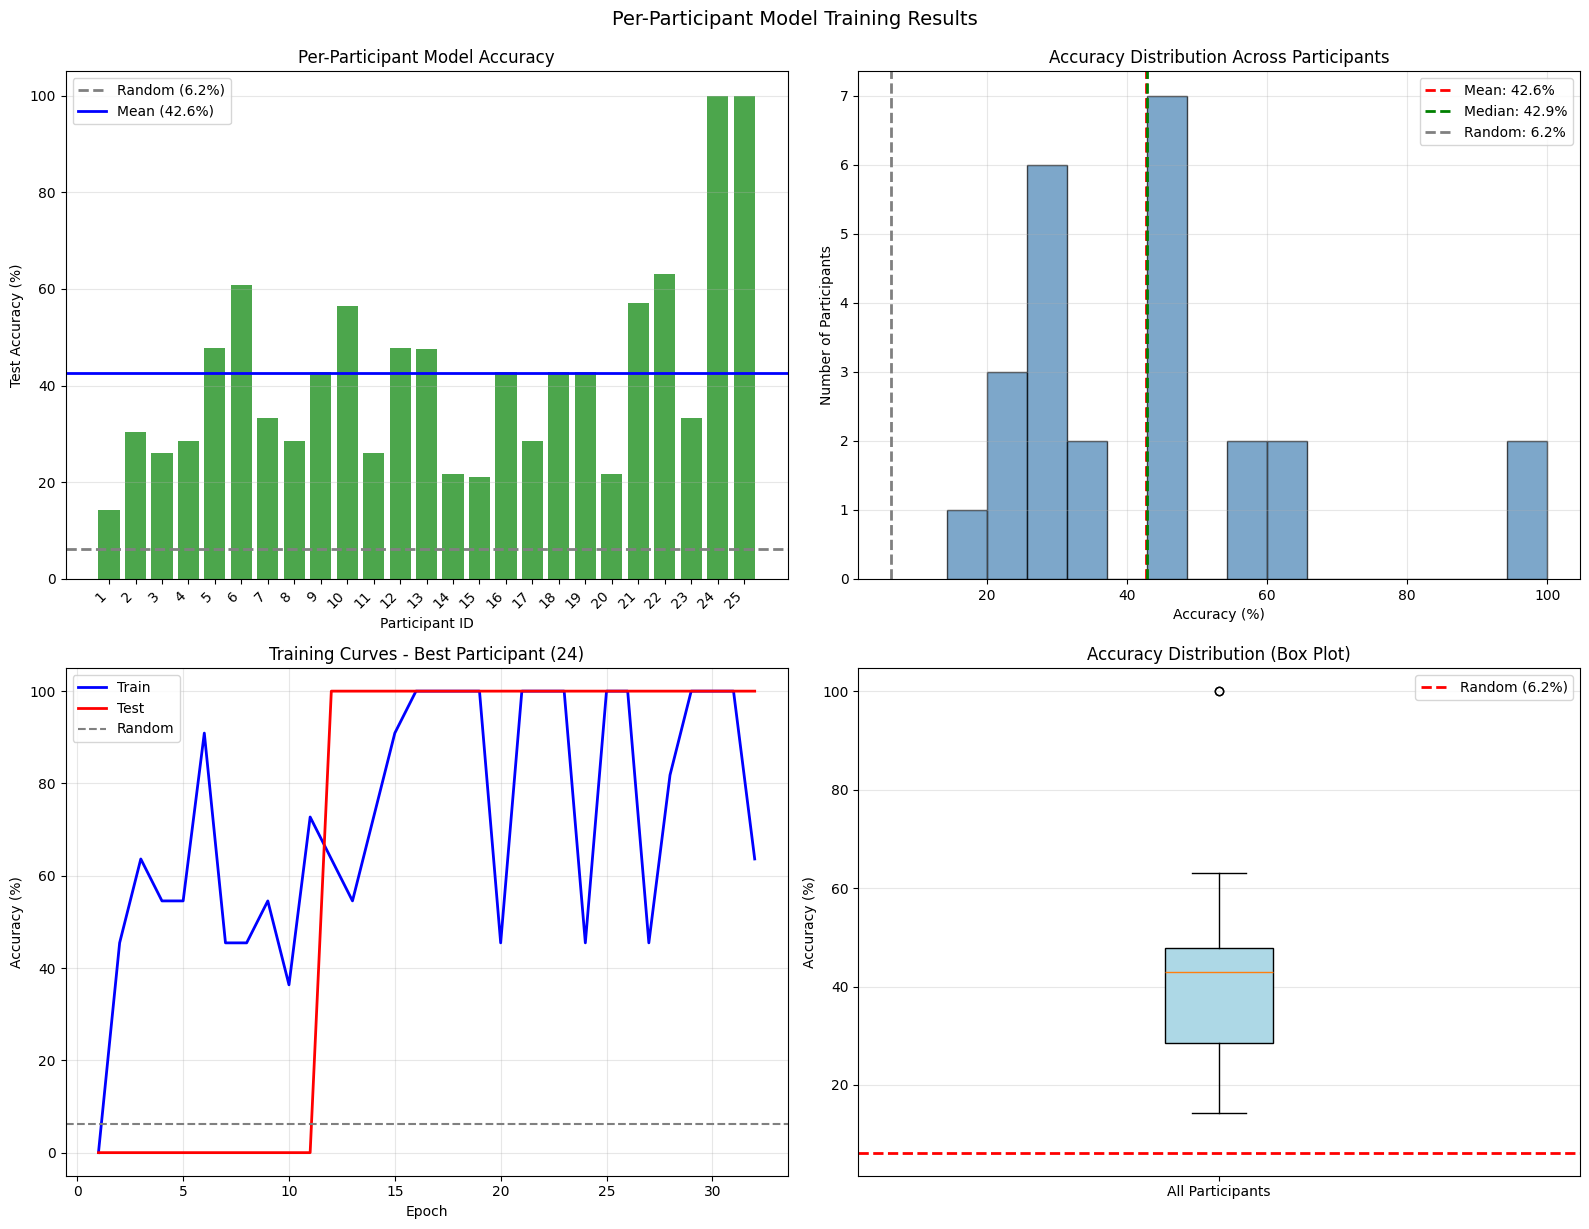

✓ Visualization saved to: per_participant_results.png


In [63]:
# ============================================================================
# PER-PARTICIPANT ACCURACY VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bar chart of accuracies per participant
ax1 = axes[0, 0]
sorted_pids = sorted(unique_participants)
sorted_accs = [participant_results[pid]['best_accuracy']
               for pid in sorted_pids]
colors = ['green' if acc > 100/N_CLASSES else 'red' for acc in sorted_accs]
bars = ax1.bar(range(len(sorted_pids)), sorted_accs, color=colors, alpha=0.7)
ax1.axhline(y=100/N_CLASSES, color='gray', linestyle='--',
            linewidth=2, label=f'Random ({100/N_CLASSES:.1f}%)')
ax1.axhline(y=np.mean(accuracies), color='blue', linestyle='-',
            linewidth=2, label=f'Mean ({np.mean(accuracies):.1f}%)')
ax1.set_xticks(range(len(sorted_pids)))
ax1.set_xticklabels(sorted_pids, rotation=45, ha='right')
ax1.set_xlabel('Participant ID')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Per-Participant Model Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Accuracy distribution histogram
ax2 = axes[0, 1]
ax2.hist(accuracies, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(x=np.mean(accuracies), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {np.mean(accuracies):.1f}%')
ax2.axvline(x=np.median(accuracies), color='green', linestyle='--',
            linewidth=2, label=f'Median: {np.median(accuracies):.1f}%')
ax2.axvline(x=100/N_CLASSES, color='gray', linestyle='--',
            linewidth=2, label=f'Random: {100/N_CLASSES:.1f}%')
ax2.set_xlabel('Accuracy (%)')
ax2.set_ylabel('Number of Participants')
ax2.set_title('Accuracy Distribution Across Participants')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Training curves for best participant
ax3 = axes[1, 0]
best_history = participant_results[best_pid]['history']
epochs_range = range(1, len(best_history['train_acc']) + 1)
ax3.plot(epochs_range, best_history['train_acc'],
         'b-', label='Train', linewidth=2)
ax3.plot(epochs_range, best_history['test_acc'],
         'r-', label='Test', linewidth=2)
ax3.axhline(y=100/N_CLASSES, color='gray', linestyle='--', label=f'Random')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy (%)')
ax3.set_title(f'Training Curves - Best Participant ({best_pid})')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Box plot of accuracy distribution
ax4 = axes[1, 1]
bp = ax4.boxplot(accuracies, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax4.axhline(y=100/N_CLASSES, color='red', linestyle='--',
            linewidth=2, label=f'Random ({100/N_CLASSES:.1f}%)')
ax4.set_ylabel('Accuracy (%)')
ax4.set_title('Accuracy Distribution (Box Plot)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticklabels(['All Participants'])

plt.tight_layout()
plt.suptitle('Per-Participant Model Training Results', fontsize=14, y=1.02)
plt.savefig('per_participant_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to: per_participant_results.png")

In [64]:
# ============================================================================
# PER-PARTICIPANT DETAILED ANALYSIS
# ============================================================================

# Analyze which participants perform well vs poorly
print("="*70)
print("DETAILED PARTICIPANT ANALYSIS")
print("="*70)

# Sort participants by accuracy
sorted_by_acc = sorted(participant_results.items(),
                       key=lambda x: x[1]['best_accuracy'], reverse=True)

print("\n📊 Participants Ranked by Accuracy:")
print("-"*50)
for rank, (pid, res) in enumerate(sorted_by_acc, 1):
    status = "🟢" if res['best_accuracy'] > 100/N_CLASSES else "🔴"
    print(
        f"  {rank:2d}. {status} Participant {pid}: {res['best_accuracy']:.2f}%")

# Calculate statistics by data size
print("\n📈 Correlation Analysis:")
data_sizes = [participant_results[pid]['n_train'] + participant_results[pid]['n_test']
              for pid in unique_participants]
acc_values = [participant_results[pid]['best_accuracy']
              for pid in unique_participants]

correlation = np.corrcoef(data_sizes, acc_values)[0, 1]
print(f"  Correlation (data size vs accuracy): {correlation:.3f}")

# Show participants with small data
print("\n⚠️ Participants with smallest datasets:")
size_sorted = sorted(zip(unique_participants, data_sizes), key=lambda x: x[1])
for pid, size in size_sorted[:5]:
    acc = participant_results[pid]['best_accuracy']
    print(f"  Participant {pid}: {size} epochs → {acc:.2f}% accuracy")

print("="*70)

DETAILED PARTICIPANT ANALYSIS

📊 Participants Ranked by Accuracy:
--------------------------------------------------
   1. 🟢 Participant 24: 100.00%
   2. 🟢 Participant 25: 100.00%
   3. 🟢 Participant 22: 63.16%
   4. 🟢 Participant 6: 60.87%
   5. 🟢 Participant 21: 57.14%
   6. 🟢 Participant 10: 56.52%
   7. 🟢 Participant 5: 47.83%
   8. 🟢 Participant 12: 47.83%
   9. 🟢 Participant 13: 47.62%
  10. 🟢 Participant 9: 42.86%
  11. 🟢 Participant 16: 42.86%
  12. 🟢 Participant 18: 42.86%
  13. 🟢 Participant 19: 42.86%
  14. 🟢 Participant 7: 33.33%
  15. 🟢 Participant 23: 33.33%
  16. 🟢 Participant 2: 30.43%
  17. 🟢 Participant 4: 28.57%
  18. 🟢 Participant 8: 28.57%
  19. 🟢 Participant 17: 28.57%
  20. 🟢 Participant 3: 26.09%
  21. 🟢 Participant 11: 26.09%
  22. 🟢 Participant 14: 21.74%
  23. 🟢 Participant 20: 21.74%
  24. 🟢 Participant 15: 21.05%
  25. 🟢 Participant 1: 14.29%

📈 Correlation Analysis:
  Correlation (data size vs accuracy): -0.716

⚠️ Participants with smallest datasets:
  P

## Per-Participant Training Complete

### Summary:
- **Approach**: Subject-Dependent (one model per participant)
- **Model**: EEG-TCNTransformer (EEGNet + TCN + Transformer)
- **Data Split**: 80% train / 20% test per participant
- **Preprocessing**: Bandpass filter (1-40 Hz) + Epoching + Baseline correction
- **Task**: 16-class Arabic word classification from imagined speech EEG

### Next Steps for Generalization:
1. **Ensemble Methods**: Combine predictions from all participant models
2. **Transfer Learning**: Fine-tune a base model on new participants
3. **Model Averaging**: Average weights across participant models
4. **Meta-Learning**: Train a model that can quickly adapt to new users

In [65]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("="*70)
print("COMPLETE PIPELINE SUMMARY - PER-PARTICIPANT TRAINING")
print("="*70)

print("\n📊 PREPROCESSING:")
print(f"  ✓ Data loaded: {len(dfs_parts)} recordings")
print(f"  ✓ EQ.Overall filtering (threshold ≥ 2)")
print(f"  ✓ Bandpass filter: 1-40 Hz (Butterworth)")
print(f"  ✓ Epoching: {epoch_duration}s windows, {overlap*100}% overlap")
print(f"  ✓ Baseline correction: {baseline_duration}s")

print(f"\n📈 DATA DIMENSIONS:")
print(f"  Original recordings: {len(dfs_parts)}")
print(f"  Final epochs: {len(X_corrected)}")
print(f"  Channels: {N_CHANNELS}")
print(f"  Timepoints per epoch: {N_TIMEPOINTS}")
print(f"  Classes: {N_CLASSES}")
print(f"  Participants: {n_participants}")

print(f"\n🧠 MODEL (per participant):")
print(f"  Architecture: EEG-TCNTransformer")
sample_model = create_model()
print(
    f"  Parameters per model: {sum(p.numel() for p in sample_model.parameters()):,}")
print(f"  Total models trained: {n_participants}")

print(f"\n📂 DATA SPLIT (Per-Participant):")
print(f"  Split ratio: 80% train / 20% test")
print(f"  Each participant trained on their own data only")

print(f"\n🎯 RESULTS:")
print(f"  Mean Accuracy:   {np.mean(accuracies):.2f}%")
print(f"  Best Accuracy:   {np.max(accuracies):.2f}% (Participant {best_pid})")
print(
    f"  Worst Accuracy:  {np.min(accuracies):.2f}% (Participant {worst_pid})")
print(f"  Random Baseline: {100/N_CLASSES:.2f}%")
print(
    f"  Participants above random: {sum(np.array(accuracies) > 100/N_CLASSES)}/{n_participants}")

print(f"\n💾 SAVED FILES:")
print(f"  participant_models/ - {n_participants} trained model files")
print(f"  per_participant_results.png - Per-participant accuracy visualization")

print("="*70)
print("✓ PER-PARTICIPANT PIPELINE COMPLETE!")
print("="*70)

COMPLETE PIPELINE SUMMARY - PER-PARTICIPANT TRAINING

📊 PREPROCESSING:
  ✓ Data loaded: 346 recordings
  ✓ EQ.Overall filtering (threshold ≥ 2)
  ✓ Bandpass filter: 1-40 Hz (Butterworth)
  ✓ Epoching: 2.0s windows, 50.0% overlap
  ✓ Baseline correction: 0.5s

📈 DATA DIMENSIONS:
  Original recordings: 346
  Final epochs: 2422
  Channels: 14
  Timepoints per epoch: 256
  Classes: 16
  Participants: 25

🧠 MODEL (per participant):
  Architecture: EEG-TCNTransformer
  Parameters per model: 1,396,992
  Total models trained: 25

📂 DATA SPLIT (Per-Participant):
  Split ratio: 80% train / 20% test
  Each participant trained on their own data only

🎯 RESULTS:
  Mean Accuracy:   42.65%
  Best Accuracy:   100.00% (Participant 24)
  Worst Accuracy:  14.29% (Participant 1)
  Random Baseline: 6.25%
  Participants above random: 25/25

💾 SAVED FILES:
  participant_models/ - 25 trained model files
  per_participant_results.png - Per-participant accuracy visualization
✓ PER-PARTICIPANT PIPELINE COMPLETE!